### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать со встроенным в `sklearn` набором данных `wine`, содержащим информацию о характеристиках трёх видов вина. Описание набора можно найти [здесь](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine) и [здесь](https://rdrr.io/cran/rattle.data/man/wine.html).

Загрузим набор данных и сохраним информацию о признаках в переменную `X`, а о зависимой переменной – в переменную `y`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_wine

data = load_wine()
X = pd.DataFrame(data['data'], columns = data['feature_names'])
y = data['target']
X.head(8)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные переменные? Если да, то закодируйте их при помощи OneHot-кодирования. Используйте [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

In [ ]:
# пропущенные значения
X.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

In [ ]:
# категориальные переменные
X.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object

### **Вывод** : все переменные числовые; пропусков в таблице нет🙂

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [ ]:
np.random.seed(1000)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y)

### Использовать аргумент stratify при разбиении важно, потому что иначе может произойти дисбаланс классов в тестовой и обучающей выборках таргета. Stratify позволяет сохранить пропорции классов в обучающем и тестовом наборах данных => нет дисбаланса (конечно, если изначально классы более менее сбалансированы).

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака: `alcohol` и `magnesium` – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
# масштабирование признаков
scaler = StandardScaler()
scaler.fit(X_train)
X_norm_train = scaler.transform(X_train)
X_norm_test = scaler.transform(X_test)
X_train2 = pd.DataFrame(X_norm_train, columns = X_train.columns)
X_test2 = pd.DataFrame(X_norm_test, columns = X_train.columns)

In [ ]:
knn = np.array([1, 3, 5, 10, 15, 25])
accuracy_train = np.array([])
accuracy_test = np.array([])
clf_list = []

for i in knn:
  clf = KNeighborsClassifier(n_neighbors = i, p = 2)
  clf_list.append(clf)
  clf.fit(X_train2[['alcohol', 'magnesium']], y_train)

  y_train_predicted = clf.predict(X_train2[['alcohol', 'magnesium']])
  y_test_predicted = clf.predict(X_test2[['alcohol', 'magnesium']])
  accuracy_train = np.append(accuracy_train, round(np.mean(y_train == y_train_predicted), 2))
  accuracy_test = np.append(accuracy_test, round(np.mean(y_test == y_test_predicted), 2))

data1 = np.concatenate([knn.reshape(-1, 1), accuracy_train.reshape(-1, 1), accuracy_test.reshape(-1, 1)], axis = 1)
df = pd.DataFrame(data1, columns = [['NN', 'Train', 'Test']])
df

,NN,Train,Test
0,1.0,1.00,0.70
1,3.0,0.77,0.69
2,5.0,0.78,0.69
3,10.0,0.77,0.70
4,15.0,0.74,0.74
5,25.0,0.71,0.72


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [ ]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [ ]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

In [ ]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools

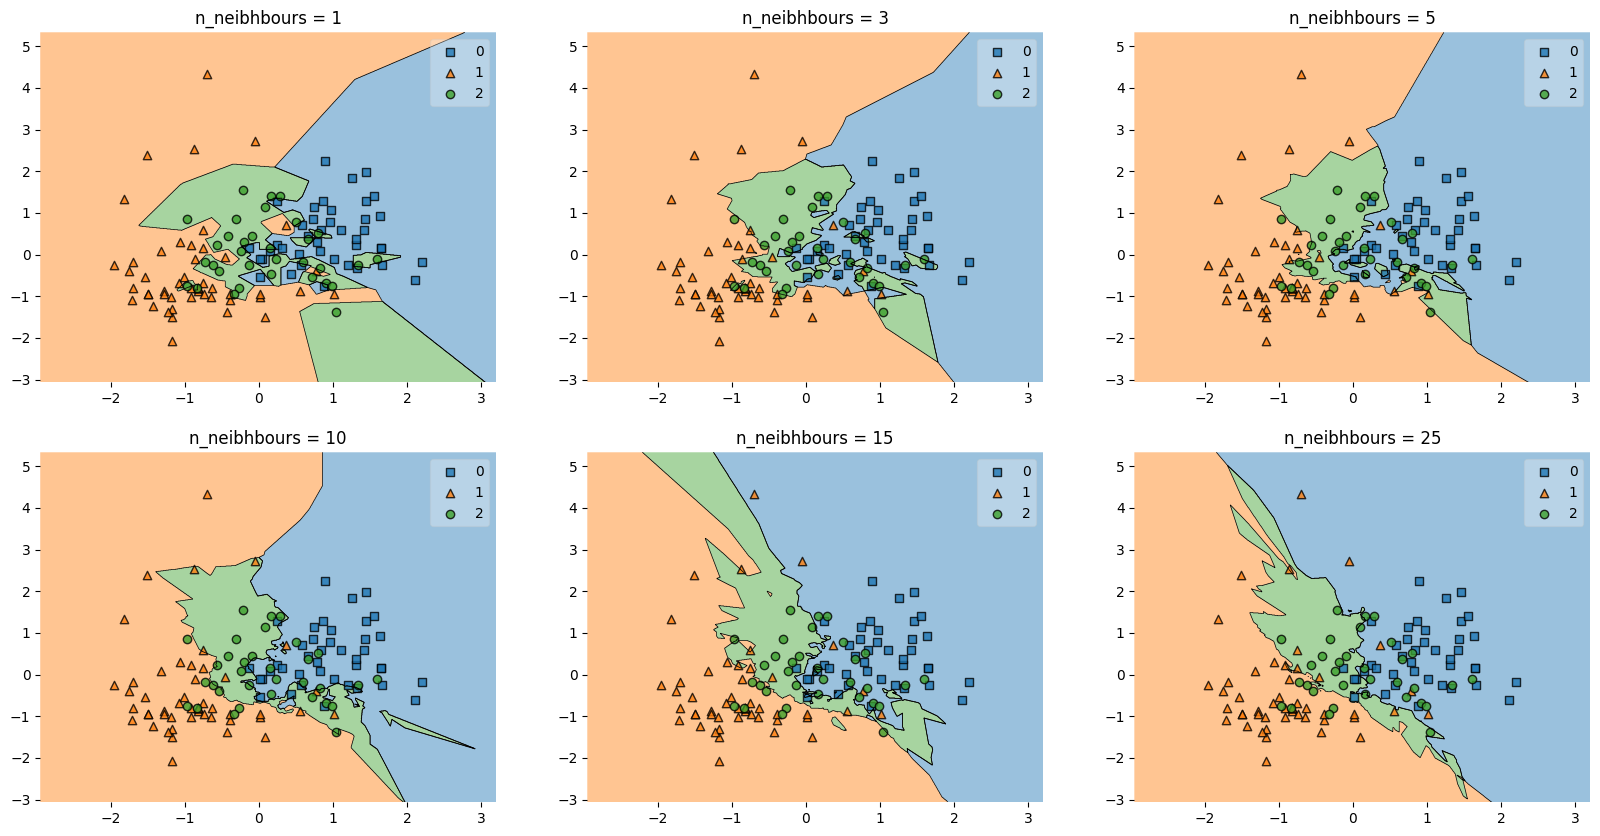

In [ ]:
gs = gridspec.GridSpec(2, 3)
fig = plt.figure(figsize = (20,10))
labels = ['n_neibhbours = 1', 'n_neibhbours = 3', 'n_neibhbours = 5', 'n_neibhbours = 10', 'n_neibhbours = 15', 'n_neibhbours = 25']

for clf, lab, grd in zip(clf_list, labels, itertools.product([0, 1], [0, 1, 2])):
  clf.fit(X_train2[['alcohol', 'magnesium']].values, y_train)
  ax = plt.subplot(gs[grd[0], grd[1]])
  fig = plot_decision_regions(X = X_train2[['alcohol', 'magnesium']].values, y = y_train, clf = clf)
  plt.title(lab)

plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

**Ответ:** Так как число соседей - гиперпараметр, его нельзя подбирать по обучающей выборке. Если смотреть на значения доли правильных ответов на тестовой выборке, то лучшим является k = 15 (доля правильных ответов = 0.74). На решающей поверхности при k = 15 классы разделены более менее (там, где основная масса синих - область выделена синим и тд)

По решающей поверхности можно сказать, что при маленьких k (1, 3) происходит переобучение модели, тк для каждого или почти каждого значения в train выделяются "островки", однако это может быть пара-тройка выбросов, которые находятся посреди другого класса.  

### Задание 2. KNN своими руками. 2 Балла

В данном задании мы попробуем реализовать алгоритм KNN своими руками. В данном случае мы попробуем сделать KNN для классификации.

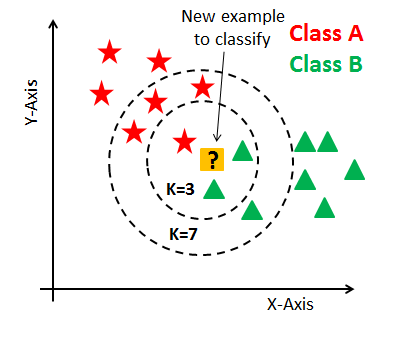

In [ ]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
        self.k = k

    def fit(self, X, y):
      self.X = X
      self.y = y
      pass

    def predict(self, X):
      y_pred = np.array([])
      for i in range(X.shape[0]):
        dist = self.count_distance(self.X, X[i])
        k_neighbors = np.argsort(dist)[:self.k]
        cnt = Counter(self.y[k_neighbors])
        y_pred = np.append(y_pred, max(cnt.items(), key = lambda x: x[1])[0])
      return y_pred
      pass

    def count_distance(self, x, y):
      return (np.sum((x - y) ** 2, axis = 1)) ** 0.5
      pass

In [ ]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [ ]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [ ]:
data = pd.read_csv('https://raw.githubusercontent.com/hse-ds/iad-intro-ds/master/2024/homeworks/hw04_knn_linreg/diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [ ]:
# пропуски
data.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

Пропущенных значений нет; есть бессмысленный столбец "Unnamed: 0", его необходимо удалить.

In [ ]:
data.drop(columns = 'Unnamed: 0', inplace = True)
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Задача 3.2 (0.1 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Выведите матрицу выборочных корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки коррелируют с целевой переменной больше всего?

In [ ]:
pd.DataFrame(data.corr(numeric_only = True))

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


### Больше всего с целевой переменной коррелируют признаки carat, x, y, z (корреляция 0,86 и более)

In [ ]:
# отделим целевую переменную
price = data['price']
data_X = data.drop(columns = 'price')

**Задача 3.3 (0.1 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные переменные при помощи OneHot-кодирования.

In [ ]:
data_X_dum = pd.get_dummies(data_X)
data_X_dum.head()

,carat,depth,table,x,y,z,cut_Fair,cut_Good,cut_Ideal,cut_Premium,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,3.95,3.98,2.43,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,3.89,3.84,2.31,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,4.05,4.07,2.31,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,4.20,4.23,2.63,0,0,0,1,...,1,0,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,4.34,4.35,2.75,0,1,0,0,...,0,1,0,0,0,1,0,0,0,0


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3. Не забудьте про параметр `stratify`.

In [ ]:
np.random.seed(666)
# здесь использовала идею из https://stats.stackexchange.com/questions/575378/stratification-of-the-continuous-y-target-variable-in-regression-setting
# то есть мы делим на классы диапазоны цен, и сохраняем исходный баланс диапазонов
bins1 = np.linspace(0, np.max(price) + 1, 50)
y_binned = np.digitize(price, bins = bins1)
data_X_train, data_X_test, price_train, price_test = train_test_split(data_X_dum, price, test_size = 0.3, stratify = y_binned)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче масштабируйте вещественные признаки тренировочной и тестовой выборок при помощи модуля `StandardScaler`.

In [ ]:
cat_X = (data_X.dtypes == 'object').values
real_col = data_X.columns[~cat_X]
real_data_X_train = data_X_train[real_col]
real_data_X_test = data_X_test[real_col]

In [ ]:
scaler2 = StandardScaler()
scaler2.fit(real_data_X_train)
data_X_norm_train = scaler2.transform(real_data_X_train)
data_X_norm_test = scaler2.transform(real_data_X_test)

real_data_X_train2 = pd.DataFrame(data_X_norm_train, columns = real_data_X_train.columns)
data_X_train2 = pd.concat([real_data_X_train2, data_X_train.drop(columns = real_col).reset_index(drop = True)], axis = 1)

real_data_X_test2 = pd.DataFrame(data_X_norm_test, columns = real_data_X_test.columns)
data_X_test2 = pd.concat([real_data_X_test2, data_X_test.drop(columns = real_col).reset_index(drop = True)], axis = 1)

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
lr = LinearRegression().fit(data_X_train2, price_train)
print(f'MSE train =', mean_squared_error(price_train, lr.predict(data_X_train2)))
print(f'MSE test =', mean_squared_error(price_test, lr.predict(data_X_test2)))

MSE train = 1277095.2230623716
MSE test = 1278057.8797921578


**Задача 3.7 (0.2 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [ ]:
# полученные оценки коэффициентов вещественных переменных
coeff = pd.DataFrame({'X': data_X_train.columns.values, 'coef': lr.coef_})
display(coeff.iloc[:6])
print('Оценки коэффициентов перемнных carat и x по модулю сильно превышают остальные.')

,X,coef
0,carat,5379.366154
1,depth,-95.866534
2,table,-61.868906
3,x,-1256.228208
4,y,82.485405
5,z,-27.665332


Оценки коэффициентов перемнных carat и x по модулю сильно превышают остальные.


**Задача 3.8 (0.4 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \frac{1}{2}\alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, уставновив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [ ]:
from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(10).fit(data_X_train2, price_train)
lasso = Lasso(10).fit(data_X_train2, price_train)
coefs = pd.DataFrame({'X': data_X_train.columns.values, 'linreg': lr.coef_, 'ridge': ridge.coef_, 'lasso': lasso.coef_})[:6]
coefs

,X,linreg,ridge,lasso
0,carat,5379.366154,5338.013893,4888.713628
1,depth,-95.866534,-94.292920,-106.359780
2,table,-61.868906,-62.119301,-78.850462
3,x,-1256.228208,-1201.128256,-754.316935
4,y,82.485405,69.347761,-0.000000
5,z,-27.665332,-31.930868,-28.666540


### Вывод: веса carat и x уменьшились в обеих моделях; в Ridge произошли несущественные изменения. В Lasso занулился признак y, коэффициенты carat и x уменьшились по модулю на ~450. Большие значения коэффициентов и наличие высокой корреляции между признаками могут говорить о сильном проявлении проблемы мультиколлинеарности, плюс к этому при попытке избавиться от этой проблемы в Lasso регрессии довольно сильно снизились коэффициенты.

**Задача 3.9 (0.4 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод агрессивнее уменьшает веса? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.346e+07, tolerance: 6.010e+07
  model = cd_fast.enet_coordinate_descent(


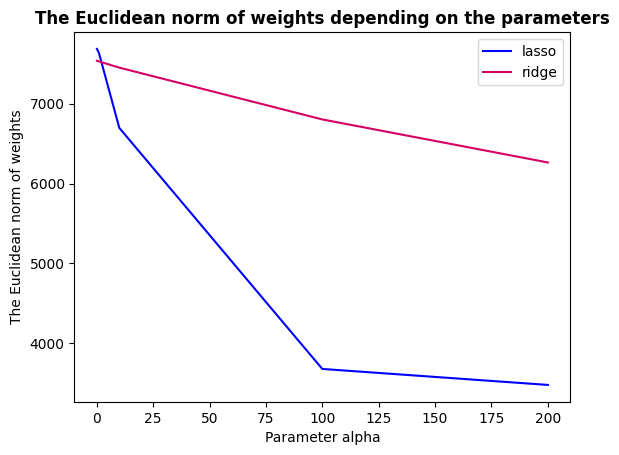

In [ ]:
alpha = [0.1, 1, 10, 100, 200]
norm_lasso = np.array([])
norm_ridge = np.array([])
for i in alpha:
    lasso2 = Lasso(i).fit(data_X_train2, price_train)
    norm_lasso = np.append(norm_lasso, np.linalg.norm(lasso2.coef_))
    ridge2 = Ridge(i).fit(data_X_train2, price_train)
    norm_ridge = np.append(norm_ridge, np.linalg.norm(ridge2.coef_))

plt.plot(alpha, norm_lasso, color = 'blue', label = 'lasso')
plt.plot(alpha, norm_ridge, color = '#D60062', label = 'ridge')
plt.xlabel('Parameter alpha')
plt.ylabel('The Euclidean norm of weights')
plt.legend()
plt.title('The Euclidean norm of weights depending on the parameters', fontweight = 'heavy')
plt.show()

### Агрессивнее уменьшает веса Lasso. Эту регрессию используют для отбора признаков, так как она может их занулять (так как в функцию потерь добавляется сумма модулей), соответственно, зануляются неинформативные признаки - это и можно считать отбором признаков.

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [ ]:
from sklearn.linear_model import LassoCV
alphas = np.array([0.1, 1, 10, 100, 200])
lasso_cv = LassoCV(cv = 5, alphas = alphas).fit(data_X_train2, price_train)

display(pd.DataFrame({'alpha': lasso_cv.alphas_, 'mse': np.mean(lasso_cv.mse_path_, axis = 1)}))
print(f'Наименьшая оценка у alpha = {lasso_cv.alphas_[np.argmin(np.mean(lasso_cv.mse_path_, axis = 1))]}')

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:617: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1802572860.105568, tolerance: 47778236.29562381
  model = cd_fast.enet_coordinate_descent_gram(


,alpha,mse
0,200.0,2.448447e+06
1,100.0,2.238785e+06
2,10.0,1.319680e+06
3,1.0,1.282557e+06
4,0.1,1.284109e+06


Наименьшая оценка у alpha = 1.0


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [ ]:
lasso3 = Lasso(1).fit(data_X_train2, price_train)
coefs2 = pd.DataFrame({'X': data_X_train.columns.values, 'lasso_coef': lasso3.coef_})
coefs2

,X,lasso_coef
0,carat,5332.440737
1,depth,-97.875461
2,table,-63.789827
3,x,-1137.824203
4,y,0.000000
5,z,-24.030974
6,cut_Fair,-652.395346
7,cut_Good,-97.443698
8,cut_Ideal,106.020514
9,cut_Premium,45.967634


### Объяснение: наиболее информативными оказались признаки carat, x и некоторые качественные признаки (color_J, clarity_I1, clarity_SI2).

Carat - вес бриллианта - оказывает наибольшее положительное влияние на цену, так как логично, что чем больше вес бриллианта, тем выше его стоимость (это также подтверждает корреляция между price и carat 0,92).

x - длина бриллианта - оказывает высокое отрицательное влияние на цену, что может быть связано с предпочтениями покупателей (люди не хотят покупать длинные бриллианты)

### Наиболее неинформативные признаки: z (небольшой коэффициент по сравнению с другими) и совсем неинформативный y (коэффициент занулился).

y - ширина и z - глубина бриллианта также могут быть связаны с предпочтениями покупателей: возможно в данном датасете исследуется сегмент рынка, где людям без разницы, какая ширина и глубина. Также причиной таких коэффициентов может быть уже упомянутая мультиколлинеарность.

У качественных признаков высокий по модулю коэффициент в основном у категорий, отвечающих за плохое качество, так как оно усиливает нежелание приобретать бриллиант. То есть обычно люди, покупающие камни, покупают их с хорошим качеством; мало кто захочет плохой бриллиант.



**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [ ]:
print(f'MSE with linear regression = {mean_squared_error(price_test, lr.predict(data_X_test2))}')
print(f'MSE with lasso regression = {mean_squared_error(price_test, lasso3.predict(data_X_test2))}')

MSE with linear regression = 1278057.8797921578
MSE with lasso regression = 1276399.760548894


### Объяснение: модель Lasso-регрессии показывает незначительно лучший результат по сравнению с обычной линейной регрессией, поэтому в данном случае лучше использовать Lasso. Причина может быть в том, что Lasso модель "откинула" ненужные признаки, а также была более эффективна в решении проблемы мультиколлинеарности.